<a href="https://colab.research.google.com/github/hawaesanda/Prediksi-Absorbansi-Daun-Selada-pada-Panjang-Gelombang-dalam-Spektrum-UV-Vis-/blob/main/Prediksi_Absorbansi_Daun_Selada_pada_Panjang_Gelombang_dalam_Spektrum_UV_Vis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [12]:
file = "/content/drive/MyDrive/Hawa Esanda/Latihan UV Vis 21 Juli 2022.xlsx"

df = pd.read_excel(file)

print(df.shape)
df.head()

(5, 186)


,No.,Type,Name,Date/Time,Note,200,205,210,215,220,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,1,Sample,UV 1264,2022-07-20 15:02:00,NaN,4.8830,4.6093,4.3077,3.9963,3.6904,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,2,Sample,UV 1265,2022-07-20 15:13:00,NaN,6.0962,5.5991,5.0360,4.4370,3.8294,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,3,Sample,UV 1266,2022-07-20 15:11:00,NaN,5.2437,5.1079,4.9146,4.6848,4.4369,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,4,Sample,UV 1267,2022-07-20 15:19:00,NaN,1.4835,1.4050,1.3324,1.2672,1.2108,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,5,Sample,UV 1268,2022-07-20 15:22:00,NaN,0.8686,1.0941,1.2534,1.3570,1.4148,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


# Cleaning data

In [13]:
drop_cols = [
    'No.',
    'Type',
    'Date/Time',
    'Note',
    'Unnamed: 186'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print(df.shape)
df.head()

(5, 182)


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,4.8830,4.6093,4.3077,3.9963,3.6904,3.4028,3.1441,2.9223,2.7428,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,UV 1265,6.0962,5.5991,5.0360,4.4370,3.8294,3.2368,2.6797,2.1752,1.7371,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,UV 1266,5.2437,5.1079,4.9146,4.6848,4.4369,4.1872,3.9494,3.7349,3.5529,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,UV 1267,1.4835,1.4050,1.3324,1.2672,1.2108,1.1642,1.1279,1.1021,1.0870,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,UV 1268,0.8686,1.0941,1.2534,1.3570,1.4148,1.4359,1.4285,1.4000,1.3570,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


## Normalisasi Min-Max per Sampel

Menormalisasikan setiap baris agar memiliki nilai minimum 0 dan maksimum 1 sebelum ditransformasi ke format long

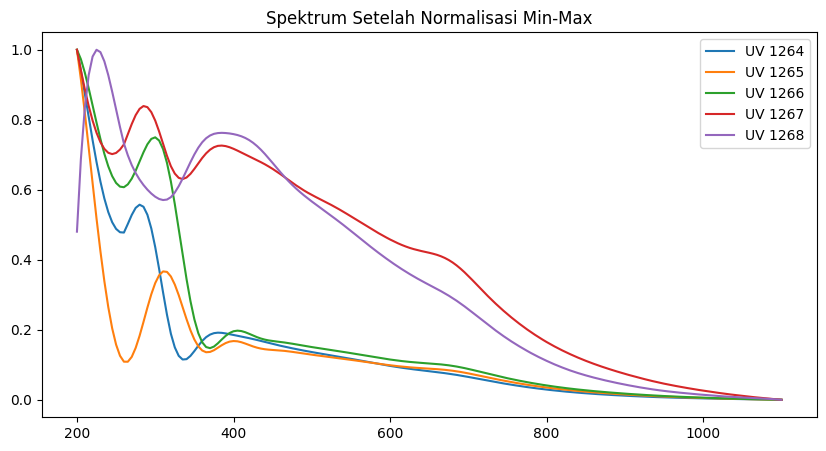

Data yang dinormalisasi telah disimpan ke 'normalized_spectra.xlsx'.


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,1.000000,0.940708,0.875371,0.807911,0.741643,0.679340,0.623297,0.575248,0.536362,...,0.001711,0.001560,0.001386,0.001235,0.001083,0.000910,0.000715,0.000498,0.000260,0
1,UV 1265,1.000000,0.916197,0.821268,0.720287,0.617856,0.517954,0.424037,0.338986,0.265130,...,0.001956,0.001736,0.001500,0.001298,0.001079,0.000860,0.000657,0.000438,0.000219,0
2,UV 1266,1.000000,0.973261,0.935201,0.889954,0.841144,0.791978,0.745156,0.702922,0.667087,...,0.002225,0.001949,0.001693,0.001437,0.001181,0.000945,0.000709,0.000473,0.000236,0
3,UV 1267,1.000000,0.941722,0.887825,0.839421,0.797550,0.762955,0.736006,0.716852,0.705642,...,0.009874,0.008612,0.007424,0.006310,0.005122,0.004083,0.002970,0.002004,0.000965,0
4,UV 1268,0.480352,0.686910,0.832830,0.927727,0.980672,1.000000,0.993222,0.967116,0.927727,...,0.005954,0.005404,0.004855,0.004305,0.003756,0.003114,0.002473,0.001740,0.000916,0


In [14]:
def normalize_spectra(dataframe):
    # Pisahkan kolom Name
    names = dataframe['Name']
    spectra = dataframe.drop(columns=['Name'])

    # Normalisasi Min-Max per baris
    normalized = spectra.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

    # Gabungkan kembali
    normalized.insert(0, 'Name', names)
    return normalized

# Terapkan pada dataset awal
df_norm = normalize_spectra(df)

# Visualisasi perbandingan setelah normalisasi
plt.figure(figsize=(10, 5))
for i in range(len(df_norm)):
    plt.plot(df_norm.columns[1:].astype(float), df_norm.iloc[i, 1:], label=df_norm.iloc[i]['Name'])

plt.title("Spektrum Setelah Normalisasi Min-Max")
plt.legend()
plt.show()

output_excel_path = 'normalized_spectra.xlsx'
df_norm.to_excel(output_excel_path, index=False)

print(f"Data yang dinormalisasi telah disimpan ke '{output_excel_path}'.")
display(pd.read_excel(output_excel_path).head())

## Skenario 1
Data train : sampel 1,2,3
Data Test : sampel 4

Sampel training baru: ['UV 1266']
Sampel validasi: ['UV 1264', 'UV 1265']
Sampel testing: ['UV 1267']

=== HASIL SETELAH NORMALISASI (RF) ===
R² (Validasi) : 0.4793
RMSE (Validasi) : 0.1250
R² (Test) : 0.0350
RMSE (Test) : 0.2782


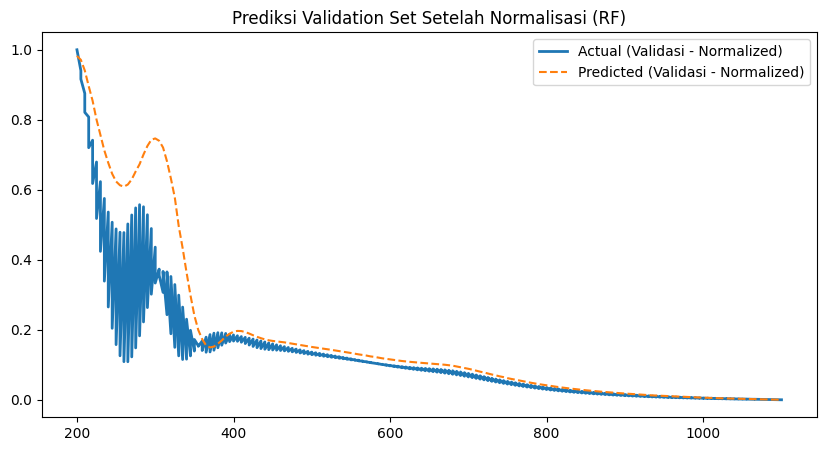

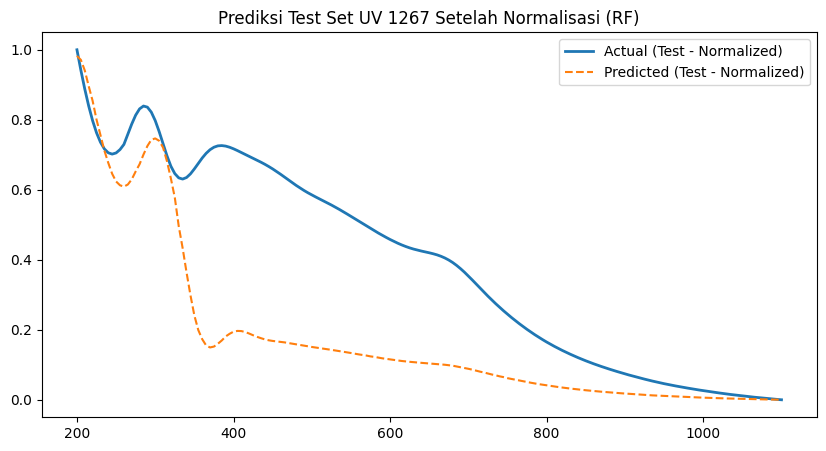

Sampel training baru: ['UV 1264']
Sampel validasi: ['UV 1265', 'UV 1266']
Sampel testing: ['UV 1267']

=== HASIL SETELAH NORMALISASI (RF) ===
R² (Validasi) : 0.7828
RMSE (Validasi) : 0.0946
R² (Test) : -0.2022
RMSE (Test) : 0.3106


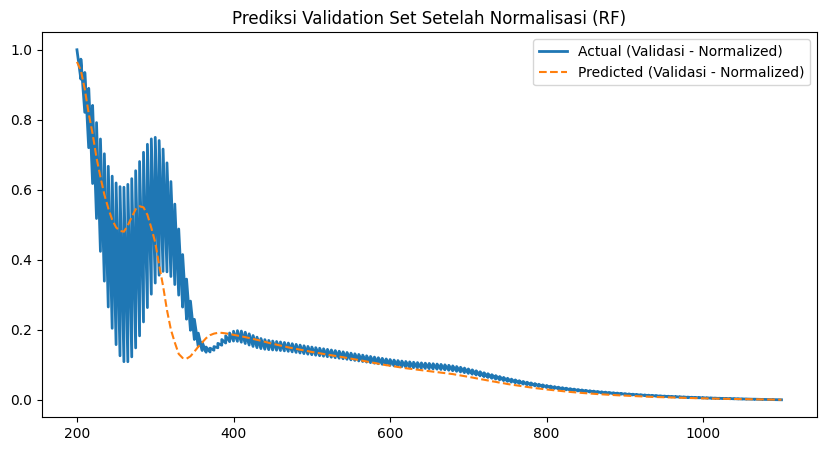

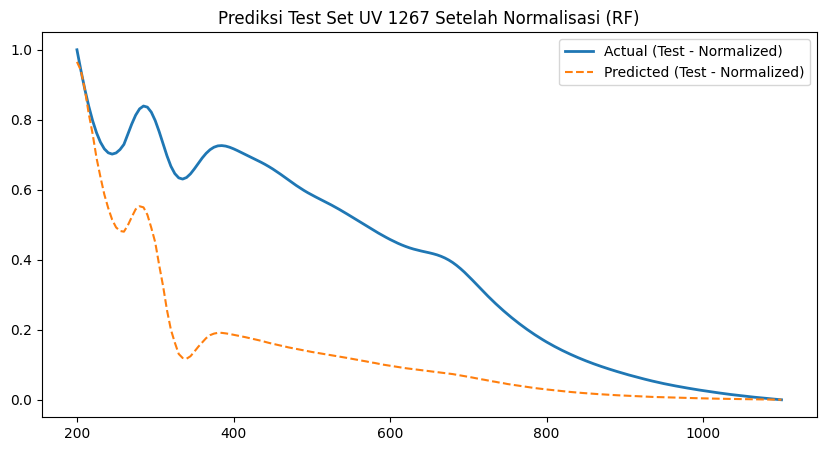

In [19]:
from sklearn.model_selection import train_test_split # Ditambahkan: Import train_test_split

# 1. Split data dari df_norm
# Dapatkan daftar nama sampel yang semula digunakan untuk training
# (UV 1264, UV 1265, UV 1266)
original_train_names = ['UV 1264', 'UV 1265', 'UV 1266']

# Split nama-nama ini menjadi 60% untuk training baru dan 40% untuk validasi
# Gunakan random_state untuk reproduktifitas
new_train_names, val_names = train_test_split(
    original_train_names,
    test_size=0.4, # 40% untuk validasi
    random_state=43 # Untuk hasil yang konsisten (diubah dari 42 ke 43)
)

# Filter df_norm berdasarkan nama-nama yang sudah dibagi
train_norm_new = df_norm[df_norm['Name'].isin(new_train_names)]
val_norm = df_norm[df_norm['Name'].isin(val_names)]

# Data test tetap seperti sebelumnya
test_norm = df_norm[df_norm['Name'] == 'UV 1267']

print(f"Sampel training baru: {new_train_names}")
print(f"Sampel validasi: {val_names}")
print(f"Sampel testing: {test_norm['Name'].unique().tolist()}")

# 2. Transform ke format long
train_norm_long = transform_data(train_norm_new) # Gunakan train_norm_new
val_norm_long = transform_data(val_norm)
test_norm_long = transform_data(test_norm)

# Assign feature and target variables for new training set
X_train_n = train_norm_long[['Wavelength']]
y_train_n = train_norm_long['Absorbance']

# Assign feature and target variables for validation set
X_val_n = val_norm_long[['Wavelength']]
y_val_n = val_norm_long['Absorbance']

# Assign feature and target variables for testing set
X_test_n = test_norm_long[['Wavelength']]
y_test_n = test_norm_long['Absorbance']

# 3. Re-fit Random Forest (menggunakan data training baru)
rf_norm = RandomForestRegressor(n_estimators=100, random_state=42)
rf_norm.fit(X_train_n, y_train_n) # Fit dengan training data baru

# Prediksi pada data validasi
pred_rf_val_n = rf_norm.predict(X_val_n)

# Prediksi pada data test
pred_rf_n = rf_norm.predict(X_test_n)

# 4. Evaluasi
# Evaluasi pada data validasi
r2_val_n = r2_score(y_val_n, pred_rf_val_n)
rmse_val_n = np.sqrt(mean_squared_error(y_val_n, pred_rf_val_n))

# Evaluasi pada data test (UV 1267)
r2_n = r2_score(y_test_n, pred_rf_n)
rmse_n = np.sqrt(mean_squared_error(y_test_n, pred_rf_n))

print(f"\n=== HASIL SETELAH NORMALISASI (RF) ===")
print(f"R² (Validasi) : {r2_val_n:.4f}")
print(f"RMSE (Validasi) : {rmse_val_n:.4f}")
print(f"R² (Test) : {r2_n:.4f}")
print(f"RMSE (Test) : {rmse_n:.4f}")

# Visualisasi Prediksi pada Validation Set
plt.figure(figsize=(10,5))
plt.plot(X_val_n['Wavelength'], y_val_n, label='Actual (Validasi - Normalized)', linewidth=2)
plt.plot(X_val_n['Wavelength'], pred_rf_val_n, label='Predicted (Validasi - Normalized)', linestyle='--')
plt.legend()
plt.title("Prediksi Validation Set Setelah Normalisasi (RF)")
plt.show()

# Visualisasi Prediksi pada Test Set (UV 1267)
plt.figure(figsize=(10,5))
plt.plot(X_test_n['Wavelength'], y_test_n, label='Actual (Test - Normalized)', linewidth=2)
plt.plot(X_test_n['Wavelength'], pred_rf_n, label='Predicted (Test - Normalized)', linestyle='--')
plt.legend()
plt.title("Prediksi Test Set UV 1267 Setelah Normalisasi (RF)")
plt.show()